In [3]:
import pickle as pkl
import hist
import numpy as np

In [25]:
a = pkl.load(open("./inputs/pythia_16_syst.pkl", "rb"))
a.keys()

dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco', 'response_matrix_u', 'response_matrix_g', 'ptjet_mjet_u_gen', 'ptjet_mjet_g_gen', 'ptz_mz_reco', 'sumw', 'nev', 'cutflow'])

In [26]:
a['ptjet_mjet_u_reco'][{'systematic':['JERUp', 'JMSUp']}]

/home/aritra/.venvs/default/lib/python3.12/site-packages/hist/basehist.py:480: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


Hist(
  StrCategory(['pythia_UL16NanoAODv9'], name='dataset'),
  StrCategory(['ee', 'mm'], growth=True, name='channel', label='Channel'),
  Variable([0, 200, 290, 400, 13000], name='ptreco', label='$p_{T,RECO}$ (GeV)'),
  Variable(array([   0.,    5.,   10.,   15.,   20.,   25.,   30.,   40.,   50.,
         60.,   70.,   80.,   90.,  100.,  110.,  120.,  130.,  140.,
        150.,  160.,  170.,  185.,  200.,  215., 1000.]), name='mreco', label='$m_{RECO}$ (GeV)'),
  StrCategory(['JERUp', 'JMSUp'], growth=True, name='systematic', label='Systematic Uncertainty'),
  storage=Weight()) # Sum: WeightedSum(value=63887, variance=8794.55)

/home/aritra/.venvs/default/lib/python3.12/site-packages/hist/basehist.py:480: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7a6545143170>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7a6545142990>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7a6549579a60>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

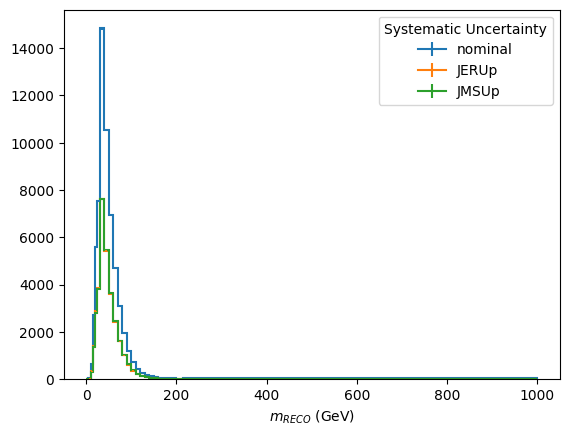

In [32]:
a['ptjet_mjet_u_reco'][{'systematic':['nominal','JERUp', 'JMSUp']}].project('systematic', 'mreco').plot(density = False)

In [2]:
outputs = [ pkl.load(open("./inputs/data16_output_no_syst.pkl", "rb")),
            pkl.load(open("./inputs/data17_output_no_syst.pkl", "rb")),
            pkl.load(open("./inputs/data18_output_no_syst.pkl", "rb"))
          ]


hist_keys = ['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco']
out_dict = {}
for i, output in enumerate(outputs):
    for key in hist_keys:
        if i == 0:
            out_dict[key] = output[key].project('ptreco', 'mreco', 'systematic')
        else:
            out_dict[key] += output[key].project('ptreco', 'mreco', 'systematic')

pkl.dump(out_dict, open("./inputs/data_all.pkl", "wb"))

In [3]:
outputs[0].keys()

dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco', 'sumw', 'nev', 'cutflow'])

In [4]:
h = outputs[0]['ptjet_mjet_u_reco'].project('ptreco', 'mreco', 'systematic')

In [5]:
h = -1*h

In [6]:
h.project('ptreco').values()

array([-61986., -71666., -19672.,  -7353.])